**Cancer Navigation Dataset Construction using NLP and Web Scraping**

**Project Overview**

This project aims to build a structured cancer navigation dataset by collecting relevant information from Dutch cancer-related websites. The workflow combines web scraping, Natural Language Processing (NLP), semantic similarity matching, and machine translation to identify relevant answers to patient navigation questions.

The project performs the following tasks:

- Scrapes healthcare information from Dutch cancer websites
- Matches patient navigation questions to relevant website content
- Translates Dutch text into English
- Categorises information into patient journey stages
- Identifies stakeholders and recommended next actions
- Produces a structured dataset for cancer navigation support

The final output is exported into Excel for analysis and reporting.

In [3]:
!pip install httpx
!pip install deepl
!pip install sentence-transformers

In [7]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from sentence_transformers import SentenceTransformer, util
import deepl
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

import os

auth_key = "insert actual deepl key"  ## Replace with actual API key for ease and simplicity or follow guidance in the README
translator = deepl.Translator(auth_key)

print("Imports successful")

Imports successful


In [13]:
print("Loading NLP model...")

model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

print("Setup completed successfully.")

Loading NLP model...


README.md: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Setup completed successfully.


In [14]:


questions = {
    'Referrals and process': [
        'How do referrals work in the Netherlands?', 
        'Can I choose my hospital or specialist?',
        'Can I change doctors?'
    ],

    'Waiting times': [
        'How long should I expect to wait for appointments or treatment?', 
        'What can I do if I feel the process is too slow?',
        'Is it normal to wait between steps?'
    ],


   'Treatment decisions': [
       'How are treatment decisions made?', 
       'Can I ask for alternative options?',
       'Do I have time to decide?'
   ],
    
    'Second opinions': [
        'Am I allowed to get a second opinion?', 
        'Can I get second opinion in another country?',
        'How do I request one?',
        'Will it be covered by insurance?'
    ],

    'Additional care and support': [
        'What additional services can I access?',
        'Psychological care',
        'Physiotherapy',
        'Nutrition advice',
        'Fertility support',
        'How do I get referred to these services?'
    ],

        
    'Communication and understanding': [
        'What if I don’t understand medical terminology?',
        'Can I request explanations in simpler language?',
        'Are there English-speaking healthcare providers?'
    ],

    'Orientation': [
        'What diagnosis and treatment pathways are available?',
        'How the system works and insurance?',
        'Referrals and navigation systems?'
    ],

    'First 48-hours after diagnosis': [
        'what happens next/immediate steps?',
        'Hospital process and points of contact?',
        'How care is organised and who is responsible?'
    ],

    'Active navigation': [
        'Support during treatment?',
        'journey overview and insurance in practice?'
    ]
} 

urls = [
    'https://www.thuisarts.nl/pijn-bij-kanker/ik-heb-pijn-bij-kanker-en-wil-behandeling-kiezen',
    'https://www.kanker.nl/hulp-en-ondersteuning/over-de-verwijsgids-kanker', 
    'https://www.commissievantoezicht.nl/kennis/dossiers/medische-zorg/vrije-artsenkeuze/vrije-artsenkeuze/',
    'https://nfk.nl/inzichten/doneer-je-ervaring-peilingen/een-ziekenhuis-kiezen-bij-kanker-wat-vind-jij-belangrijk',
    'https://www.zorgwijzer.nl/faq/patientenrechten#second-opinion',
    'https://www.kanker.nl/algemene-onderwerpen/je-keuzes-en-rechten-als-kankerpatient/algemeen/wachttijden-bij-ziekenhuizen-voor-kanker',
    'https://www.kanker.nl/algemene-onderwerpen/je-keuzes-en-rechten-als-kankerpatient/algemeen/wachttijden-bij-ziekenhuizen-voor-kanker#wat',
    'https://www.zorgkaartnederland.nl/wachttijden',
    'https://www.kanker.nl/algemene-onderwerpen/in-gesprek-met-je-arts/algemeen/in-gesprek-met-je-arts-over-de-behandeling',
    'https://www.kanker.nl/algemene-onderwerpen/in-gesprek-met-je-arts/algemeen/hoe-vind-je-betrouwbare-informatie',
    'https://www.kanker.nl/algemene-onderwerpen/je-keuzes-en-rechten-als-kankerpatient/algemeen/second-opinion-bij-kanker',
    'https://www.zorgwijzer.nl/faq/patientenrechten#second-opinion'
    'https://www.kanker.nl/gevolgen-van-kanker/niet-meer-beter-worden/palliatieve-zorg/psychosociale-zorg-bij-ongeneeslijke-kanker',
    'https://www.zorgwijzer.nl/vergoeding/fysiotherapie',
    'https://www.kanker.nl/algemene-onderwerpen/gezond-leven-met-en-na-kanker/themas-gezond-leven-bij-kanker/voeding-en-kanker',
    'https://www.kanker.nl/gevolgen-van-kanker/vruchtbaarheid-en-kanker/kanker-en-vruchtbaarheid-bij-vrouwen/anti-hormonale-therapie-en-vruchtbaarheid-bij-vrouwen',
    'https://www.zorginstituutnederland.nl/verzekerde-zorg/h/huisarts-zvw',
    'https://www.thuisarts.nl/vertalingen-op-thuisarts',
    'https://www.kanker.nl/zorgprofessionals/woordenboeken',
    'https://www.kanker.nl/hulp-en-ondersteuning/stel-je-vraag-aan-een-professional',
    'https://www.teladochealth.nl/',
    'https://www.kanker.nl/gevolgen-van-kanker/vruchtbaarheid-en-kanker/kanker-en-vruchtbaarheid-bij-mannen/je-vruchtbaarheid-testen-na-de-behandeling',
    'https://www.rijksoverheid.nl/onderwerpen/zorgverzekering/vraag-en-antwoord/wat-zit-er-in-het-basispakket-van-de-zorgverzekering',
    'https://www.avl.nl/verwijzers/',
    'https://www.avl.nl/voorbereiding-afspraak/afdelingen-en-centra/centrum-patienteninformatie/',
    'https://www.kanker.nl/gevolgen-van-kanker/kanker-wat-nu/diagnose-kanker/kanker-wat-nu',
    'https://iknl.nl/over-iknl/wat-we-doen',
    'https://www.kanker.nl/hulp-en-ondersteuning/vind-hulp-bij-kanker',
    'https://www.zorgwijzer.nl/zorgwijzers/kanker'
    
]



In [15]:
## USER DEFINED/HELPER FUNCTIONS FOR WEB SCRAPPING
def scrape_website(url):

    try:

        response = requests.get(
            url,
            timeout=15,
            headers={
                "User-Agent":
                "Mozilla/5.0"
            }
        )

        if response.status_code != 200:

            print(f"Failed: {url}")

            return []

        soup = BeautifulSoup(
            response.text,
            'html.parser'
        )

        paragraphs = soup.find_all('p')

        text_list = []

        for paragraph in paragraphs:

            text = paragraph.get_text(
                strip=True
            )

            if len(text) > 40:

                text_list.append(text)

        return text_list

    except Exception as e:

        print(
            f"Error scraping {url}: {e}"
        )

        return []

In [16]:
## TESTING WEB SCRAPPER
sample_text = scrape_website(
    urls[0]
)

print(
    "Paragraphs found:",
    len(sample_text)
)

print(sample_text[:3])

Paragraphs found: 58
['Beldirectje arts of verpleegkundige als je zoveel pijn hebt dat je het niet meer volhoudt. Of laat iemand anders voor jou bellen.', 'Bel ook als je pijn hebt en 1 of meer van deze klachten:', 'Maak een afspraakmet de arts of verpleegkundige bij 1 of meer van deze dingen:']


In [17]:
## SEMANTIC MATCHING FUNCTION 
## “Questions were translated into Dutch prior to semantic similarity matching to improve alignment between 
## English user queries and Dutch source content.”
def find_best_match(
    question,
    paragraphs
):

    if len(paragraphs) == 0:
        return None, 0

    try:
        dutch_question = translator.translate_text(
            question,
            target_lang="NL"
        ).text

    except:
        dutch_question = question

    question_embedding = model.encode(
        dutch_question,
        convert_to_tensor=True
    )

    paragraph_embeddings = model.encode(
        paragraphs,
        convert_to_tensor=True
    )

    similarity_scores = util.cos_sim(
        question_embedding,
        paragraph_embeddings
    )[0]

    best_index = similarity_scores.argmax()

    best_score = float(
        similarity_scores[
            best_index
        ]
    )

    best_text = paragraphs[
        best_index
    ]

    return best_text, best_score

In [18]:
## TEXTING MATCHING FUNCTION WITH ONE QUESTION
question = (
    "Am I allowed to get a second opinion?"
)

best_text, score = find_best_match(
    question,
    sample_text
)

print("Score:", score)
print("\nMatched text:\n")
print(best_text)

Score: 0.6092877388000488

Matched text:

Als je zenuwpijn hebt, helpen gewone pijnstillers meestal niet goed. Je kunt dan andere medicijnen proberen.


In [19]:
## CREATING TRANSLATION FUNCTION
def translate_text(text):

    try:

        translated = translator.translate_text(
            text,
            target_lang="EN-GB"
        ).text

        return translated

    except:

        return text

In [20]:
## TESTING TRANSLATION
translate_text(
    sample_text[0]
)

'Call a doctor or nurse straight away if you’re in so much pain that you can’t cope any longer. Or get someone else to call for you.'

In [21]:
## HELPER FUNCTIONS FOR METADATA

from urllib.parse import urlparse


def get_source_organisation(url):

    domain = urlparse(url).netloc

    if "kanker.nl" in domain:
        return "Kanker.nl"

    elif "kwf.nl" in domain:
        return "KWF Kankerbestrijding"

    elif "iknl.nl" in domain:
        return "Integraal Kankercentrum Nederland"

    else:
        return domain


def get_page_title(url):

    try:

        response = requests.get(
            url,
            timeout=15,
            
        )

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        if soup.title:
            return soup.title.text.strip()

        return "Unknown Page"

    except:
        return "Unknown Page"


def create_summary(text):

    if not text:
        return ""

    sentences = text.split(".")

    if len(sentences) >= 2:
        return (
            sentences[0].strip()
            + ". "
            + sentences[1].strip()
            + "."
        )

    return text

In [22]:
## Classification functions
def determine_stage(topic):

    topic = topic.lower()

    if "referral" in topic:
        return "Referral"

    elif "diagnosis" in topic:
        return "Diagnosis"

    elif "treatment" in topic:
        return "Treatment"

    elif "support" in topic:
        return "Support"

    elif "survivorship" in topic:
        return "Follow-up"

    else:
        return "General"


def determine_priority(score):

    if score >= 0.50:
        return "High"

    elif score >= 0.30:
        return "Medium"

    else:
        return "Low"


def determine_stakeholder(topic):

    topic = topic.lower()

    if "treatment" in topic:
        return "Healthcare Professional"

    elif "support" in topic:
        return "Support Service"

    else:
        return "Healthcare System"


def determine_next_step(topic):

    topic = topic.lower()

    if "referral" in topic:
        return "Consult GP"

    elif "treatment" in topic:
        return "Discuss Treatment Options"

    elif "support" in topic:
        return "Access Support Services"

    else:
        return "Seek Further Information"

In [23]:
## CREATING THE DATASET

dataset = []

for topic, question_list in questions.items():

    for question in question_list:

        print(f"\nProcessing:")
        print(question)

        best_text = None
        best_score = 0
        best_url = ""

        for url in urls:

            paragraphs = scrape_website(
                url
            )

            matched_text, score = (
                find_best_match(
                    question,
                    paragraphs
                )
            )

            if (
                matched_text
                and score > best_score
            ):

                best_score = score
                best_text = matched_text
                best_url = url

        scrape_date = (
            datetime.today()
            .strftime("%Y-%m-%d")
        )

        source_org = (
            get_source_organisation(
                best_url
            )
            if best_url
            else "Unknown"
        )

        source_title = (
            get_page_title(
                best_url
            )
            if best_url
            else "Unknown"
        )

        if best_text is None:

            dataset.append({

                "Source Organisation":
                    source_org,

                "Source Title":
                    source_title,

                "Scrape Date":
                    scrape_date,

                "Topic":
                    topic,

                "Question":
                    question,

                "Matched Dutch Text":
                    "No match found",

                "English Translation":
                    "",

                "Summary / Answer Text":
                    "",

                "Similarity Score":
                    0,

                "Priority":
                    "Low",

                "Patient Journey Stage":
                    determine_stage(
                        topic
                    ),

                "Stakeholder":
                    determine_stakeholder(
                        topic
                    ),

                "Action / Next Step":
                    determine_next_step(
                        topic
                    ),

                "URL":
                    ""
            })

        else:

            translated_text = (
                translate_text(
                    best_text
                )
            )

            summary = (
                create_summary(
                    translated_text
                )
            )

            dataset.append({

                "Source Organisation":
                    source_org,

                "Source Title":
                    source_title,

                "Scrape Date":
                    scrape_date,

                "Topic":
                    topic,

                "Question":
                    question,

                "Matched Dutch Text":
                    best_text,

                "English Translation":
                    translated_text,

                "Summary / Answer Text":
                    summary,

                "Similarity Score":
                    round(
                        best_score,
                        3
                    ),

                "Priority":
                    determine_priority(
                        best_score
                    ),

                "Patient Journey Stage":
                    determine_stage(
                        topic
                    ),

                "Stakeholder":
                    determine_stakeholder(
                        topic
                    ),

                "Action / Next Step":
                    determine_next_step(
                        topic
                    ),

                "URL":
                    best_url
            })

print("\nDone!")


Processing:
How do referrals work in the Netherlands?

Processing:
Can I choose my hospital or specialist?

Processing:
Can I change doctors?

Processing:
How long should I expect to wait for appointments or treatment?

Processing:
What can I do if I feel the process is too slow?

Processing:
Is it normal to wait between steps?

Processing:
How are treatment decisions made?

Processing:
Can I ask for alternative options?

Processing:
Do I have time to decide?

Processing:
Am I allowed to get a second opinion?

Processing:
Can I get second opinion in another country?

Processing:
How do I request one?

Processing:
Will it be covered by insurance?

Processing:
What additional services can I access?

Processing:
Psychological care

Processing:
Physiotherapy

Processing:
Nutrition advice

Processing:
Fertility support

Processing:
How do I get referred to these services?

Processing:
What if I don’t understand medical terminology?

Processing:
Can I request explanations in simpler languag

In [24]:
len(dataset)

30

In [26]:
## Cell 15, Create DF
df = pd.DataFrame(dataset)

print(df.shape)

df.head()

(30, 14)


,Source Organisation,Source Title,Scrape Date,Topic,Question,Matched Dutch Text,English Translation,Summary / Answer Text,Similarity Score,Priority,Patient Journey Stage,Stakeholder,Action / Next Step,URL
0,Kanker.nl,Kanker.nl woordenboeken: van medisch jargon na...,2026-09-16,Referrals and process,How do referrals work in the Netherlands?,Hetproject Begrijpelijke taal in de zorgwordt ...,The ‘Plain Language in Healthcare’ project is ...,The ‘Plain Language in Healthcare’ project is ...,0.744,High,Referral,Healthcare System,Consult GP,https://www.kanker.nl/zorgprofessionals/woorde...
1,Kanker.nl,Over de verwijsgids Kanker | Kanker.nl,2026-09-16,Referrals and process,Can I choose my hospital or specialist?,De uitgever van de Verwijsgids Kanker is IKNL ...,The publisher of the Cancer Referral Guide is ...,The publisher of the Cancer Referral Guide is ...,0.670,High,Referral,Healthcare System,Consult GP,https://www.kanker.nl/hulp-en-ondersteuning/ov...
2,www.thuisarts.nl,Ik heb pijn bij kanker en wil een behandeling ...,2026-09-16,Referrals and process,Can I change doctors?,Maak een afspraakmet de arts of verpleegkundig...,Make an appointment with a doctor or nurse if ...,Make an appointment with a doctor or nurse if ...,0.716,High,Referral,Healthcare System,Consult GP,https://www.thuisarts.nl/pijn-bij-kanker/ik-he...
3,Kanker.nl,Wachttijden bij ziekenhuizen voor kanker | Kan...,2026-09-16,Waiting times,How long should I expect to wait for appointme...,Elk ziekenhuis heeft wachttijden voor een afsp...,Every hospital has waiting times for appointme...,Every hospital has waiting times for appointme...,0.758,High,General,Healthcare System,Seek Further Information,https://www.kanker.nl/algemene-onderwerpen/je-...
4,Kanker.nl,In gesprek met je arts over de behandeling | k...,2026-09-16,Waiting times,What can I do if I feel the process is too slow?,Spreek je niet zo goed Nederlands? Dan is een ...,"Do you not speak Dutch very well? If so, a con...","Do you not speak Dutch very well? If so, a con...",0.654,High,General,Healthcare System,Seek Further Information,https://www.kanker.nl/algemene-onderwerpen/in-...


In [27]:
## Quality Checks
df[
    [
        "Question",
        "Similarity Score",
        "Priority"
    ]
].sort_values(
    by="Similarity Score",
    ascending=False
)

,Question,Similarity Score,Priority
3,How long should I expect to wait for appointme...,0.758,High
21,Are there English-speaking healthcare providers?,0.757,High
0,How do referrals work in the Netherlands?,0.744,High
9,Am I allowed to get a second opinion?,0.740,High
10,Can I get second opinion in another country?,0.737,High
20,Can I request explanations in simpler language?,0.734,High
28,Support during treatment?,0.729,High
2,Can I change doctors?,0.716,High
8,Do I have time to decide?,0.713,High
11,How do I request one?,0.707,High


In [32]:
## Check for missing matches

df[
    df[
        "Matched Dutch Text"
    ] == "No match found"
]

,Source Organisation,Source Title,Scrape Date,Topic,Question,Matched Dutch Text,English Translation,Summary / Answer Text,Similarity Score,Priority,Patient Journey Stage,Stakeholder,Action / Next Step,URL


In [28]:
## Save to Excel
output_file = (
    "Cancer_Navigation_Dataset6.xlsx"
)

df.to_excel(
    output_file,
    index=False
)

print(
    "Dataset saved successfully"
)

Dataset saved successfully


## ANALYSIS 

**EDA for Initial Insights**

This section seeks to explore the dataset for initial insights using Exploratory Data Analysis. 
These will include:
- Similarity score summary
- Priority distribution
- Patient journey
- Source organisation frequency
- Highest vrs lowest semantic matches

## Similarity Score

This is to evaluate how well the NLP model matched questions to website content.
This will answer questions such as:
- Were matches generally strong or weak
- Which questions were poorly retrieved

In [29]:
df["Similarity Score"].describe()

count    30.000000
mean      0.660700
std       0.071249
min       0.515000
25%       0.617000
50%       0.668000
75%       0.715250
max       0.758000
Name: Similarity Score, dtype: float64

**Insight**

The focus here is the mean, which is 66%. This suggests moderate to strong alignment between 
patient questions and retrieved website content.

## Priority Distribution

This is to identify which matches were high, medium and low priority

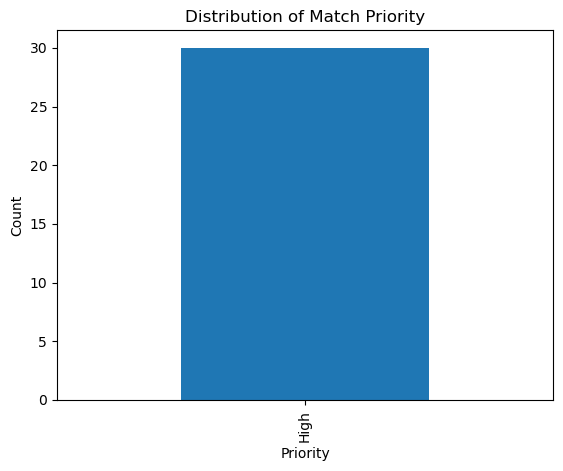

In [30]:
df["Priority"].value_counts()

import matplotlib.pyplot as plt

df["Priority"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Distribution of Match Priority"
)

plt.ylabel("Count")

plt.show()

**Insight**

Most retrieved answers were classified as high priority. Indicating that the semantic retrieval model
did retrieve high relevant information for majority of the questions.

## Patient Journey Stage Distribution

This is to understand which stage of cancer care are most represented.

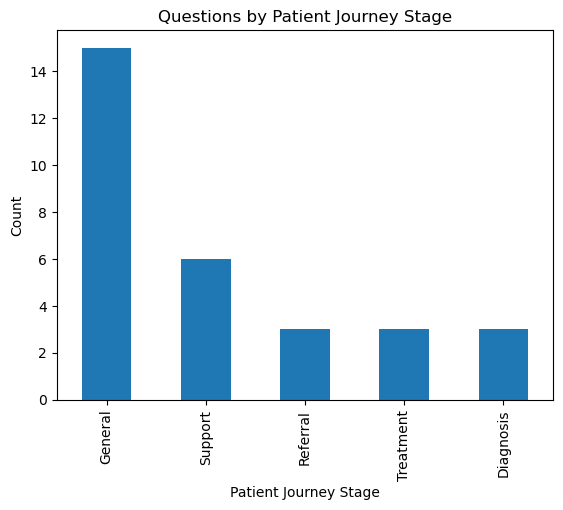

In [31]:
df[
    "Patient Journey Stage"
].value_counts()

df[
    "Patient Journey Stage"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Questions by Patient Journey Stage"
)

plt.ylabel("Count")

plt.show()

**Insight**

The General stage of the patient journey contained the highest number of navigation questions, 
indicating seeking general information was most prevalent among cancer patients.
This could indicate the importance of general information.

## Source Organisation Analysis ##

This seeks to indicate which website contributed most answers


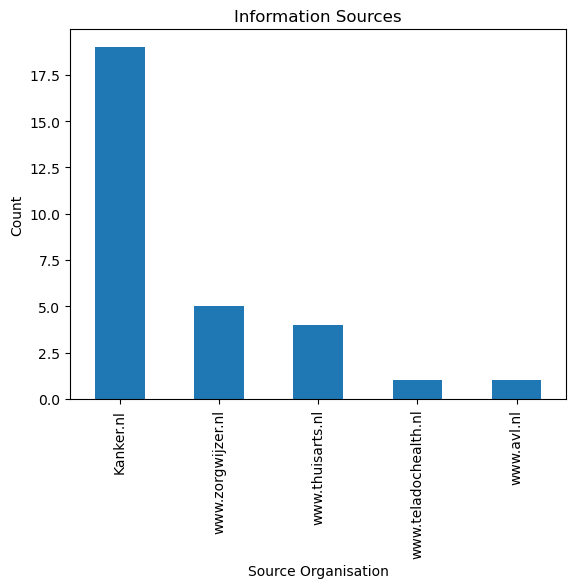

In [32]:
df[
    "Source Organisation"
].value_counts()

df[
    "Source Organisation"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Information Sources"
)

plt.ylabel("Count")

plt.show()

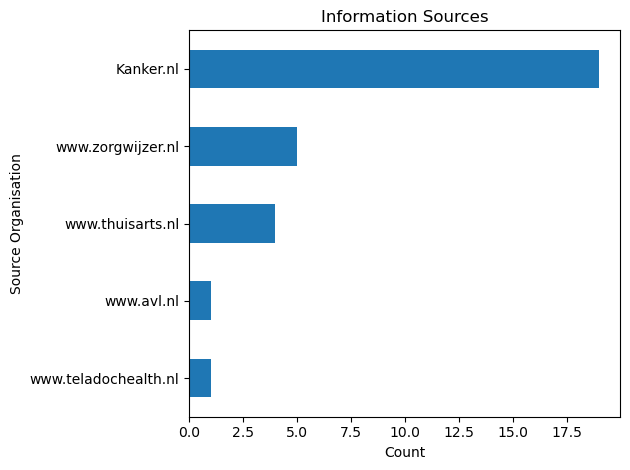

In [34]:
df["Source Organisation"].value_counts().sort_values().plot(
    kind="barh"
)

plt.title("Information Sources")
plt.xlabel("Count")
plt.ylabel("Source Organisation")
plt.tight_layout()
plt.show()

**Insight**

Out of the cancer organisations in the Netherlands, kanker.nl contributed majority of the retrieved information.
This indicates the concentration of navigation information within the Kanker organisation.

In [ ]:
df["Source Organisation"].value_counts().plot(
    kind="barh"
)

plt.title("Information Sources")
plt.xlabel("Count")
plt.ylabel("Source Organisation")
plt.tight_layout()
plt.show()

## Highest and Lowest Semantic Matches

This is to indicate the areas of retrieved information to manually inspect for quality.

In [35]:
## Top-half Matches
df.sort_values(
    by="Similarity Score",
    ascending=False
)[
    [
        "Question",
        "Similarity Score",
        "Summary / Answer Text"
    ]
].head(10)

,Question,Similarity Score,Summary / Answer Text
3,How long should I expect to wait for appointme...,0.758,Every hospital has waiting times for appointme...
21,Are there English-speaking healthcare providers?,0.757,You can get help from various healthcare profe...
0,How do referrals work in the Netherlands?,0.744,The ‘Plain Language in Healthcare’ project is ...
9,Am I allowed to get a second opinion?,0.740,Requesting a second opinion can sometimes take...
10,Can I get second opinion in another country?,0.737,Requesting a second opinion can sometimes take...
20,Can I request explanations in simpler language?,0.734,Do you have a question about cancer and would ...
28,Support during treatment?,0.729,Side effects often occur during cancer treatme...
2,Can I change doctors?,0.716,Make an appointment with a doctor or nurse if ...
8,Do I have time to decide?,0.713,That’s good to hear! Do you have any further c...
11,How do I request one?,0.707,A number of sections on the kanker. nl platfor...


In [36]:
## Lower-half Matches
df.sort_values(
    by="Similarity Score"
)[
    [
        "Question",
        "Similarity Score",
        "Summary / Answer Text"
    ]
].head(10)

,Question,Similarity Score,Summary / Answer Text
16,Nutrition advice,0.515,Further information on healthy eating: the Net...
14,Psychological care,0.525,What we doOur solutionsFor businessesFor users...
5,Is it normal to wait between steps?,0.531,Would you like to know how long the waiting ti...
17,Fertility support,0.564,"Cancer takes a heavy toll on you, both physica..."
6,How are treatment decisions made?,0.573,You may have come across information about alt...
26,Hospital process and points of contact?,0.580,Have you contacted your health insurer about t...
23,How the system works and insurance?,0.591,The risk of infertility caused by hormone ther...
19,What if I don’t understand medical terminology?,0.612,"Kanker. nl has now explained more than 1,000 m..."
24,Referrals and navigation systems?,0.632,A third opinion is not usually covered by heal...
18,How do I get referred to these services?,0.652,"Cancer can make you feel, for example, down, s..."


**Insight**
- From the top-half matches, even though there are high matching scores (69% to 80%) between questions and retrieved answers,
manual inspection reveals moderate relevance of the retrieved answers.
- From the lower-half matches, manual inspection reveals little relevance of the retrieved answers to the questions even
though similarity scores range between 65% to 50%.

This could reflect limited information availability or semantic matching difficulty.


## CONCLUSION

The methodology, tool and techniques applied in this notebook has produced a dataset enriched with structured metadata
tags to suuport future patient vagivation chhatbot development.
This included topic category, patient journey stage, stakeholder type, recommended vext action, source organisation,
semantic similarity confidence score and relevance priority.
Such tagging enables future conversational systems to retrieve contextually appropriate responses and personal support.